# L15 Cross Validation & Regularization

- Cross Validation

- Regularization & Scaling

**Motivations**

- A model that’s too complex can lead to overfitting while a model that’s too simple can lead to underfitting

**How to find the sweet point?**

- We need to understand when the model starts to overfit by assessing its performance on unseen data (Cross-validation)

- Then use a technique to adjust the complexity of our models ourselves (Regularization)

## 1 Cross Validation

### Training, Test, and Validation Sets

- The only way to know when our model overfits is by evaluating it on **unseen data**
  
- Unfortunately, that means we need to **wait for more data**. This may be very expensive and time-consuming

**Test Sets & Training Sets**

- The simplest approach to avoid overfitting is to **keep some of our data “secret” from ourselves**

- We only ever make predictions on the test set **once** after all model design has been completely finalized. We treat the test set performance as the final test of how well a model does

- We can’t go back and adjust our model based on the new discovery that it is overfitting. If we did, then we would be **factoring in information from the test set to design our model**. The test error would no longer be a true representation of the model’s performance on unseen data

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

- **The test set is only ever touched once**: to compute the performance of the model after all fine-tuning has been completed

</div>

- The process of sub-dividing our dataset into training and test sets is known as a **train-test split**

  - Typically 10%-20% is to the test set (Since a more accurate model needs nore data to train)

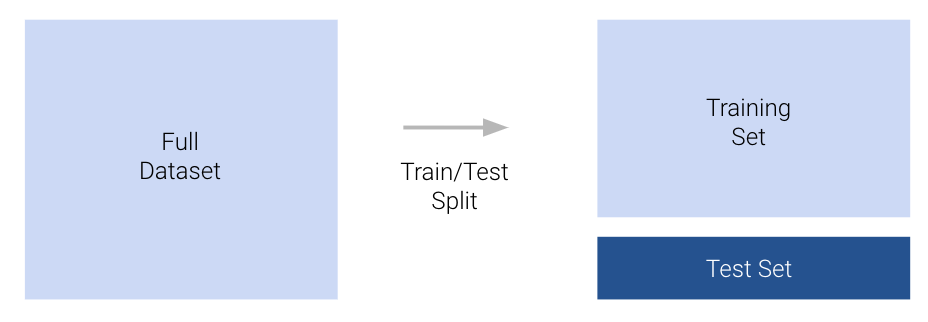

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset and construct the design matrix
vehicles = sns.load_dataset("mpg").rename(columns={"horsepower":"hp"}).dropna()
X = vehicles[["hp"]]
X["hp^2"] = vehicles["hp"]**2
X["hp^3"] = vehicles["hp"]**3
X["hp^4"] = vehicles["hp"]**4

Y = vehicles["mpg"]

- We allocate 20% of the full dataset to testing, and the remaining 80% to training

In [8]:
from sklearn.model_selection import train_test_split

# `test_size` specifies the proportion of the full dataset that should be allocated to testing
# `random_state` makes our results reproducible for educational purposes
X_train, X_test, Y_train, Y_test = train_test_split(
        X, 
        Y, 
        test_size=0.2, 
        random_state=220
    )

print(f"Size of full dataset: {X.shape[0]} points")
print(f"Size of training set: {X_train.shape[0]} points")
print(f"Size of test set: {X_test.shape[0]} points")

Size of full dataset: 392 points
Size of training set: 313 points
Size of test set: 79 points


- After train-test split, we fit a model to it

In [9]:
import sklearn.linear_model as lm
from sklearn.metrics import mean_squared_error

model = lm.LinearRegression()

# Fit to the training set
model.fit(X_train, Y_train)

# Calculate errors
train_error = mean_squared_error(Y_train, model.predict(X_train))
test_error = mean_squared_error(Y_test, model.predict(X_test))

print(f"Training error: {train_error}")
print(f"Test error: {test_error}")

Training error: 17.85851684101209
Test error: 23.192405630290544


**Validation Sets**

- What if we are **dissatisfied with** our test set performance?

- Remember, the test set can only be touched **once**! But we already use it

- We need to modify our framework by introducing a **validation set**: a random portion of the training set that is set aside for assessing model performance **while the model is still being developed**

- The process of creating a validation set is called a **validation split**

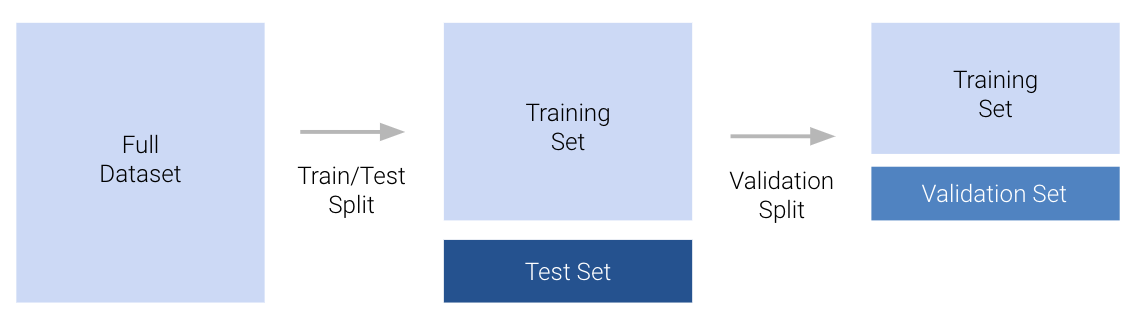

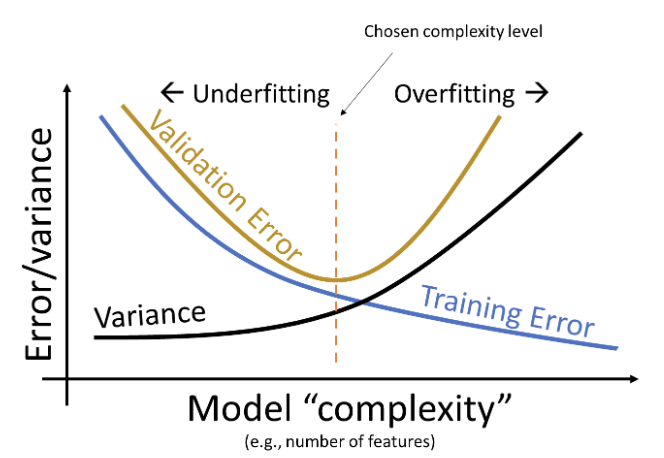

- As the model becomes more complex, it makes better predictions on the training data; the variance of the model typically increases as model complexity increases
  
- Validation error decreases then increases as we increase model complexity (There is a sweet point)

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- We need to minimize the validation error

</div>

### K-Fold Cross-Validation

- But what if, by random chance, **our validation set just happened to contain many outliers**?

- Ideally, we would like to **validate our model’s performance on several different unseen datasets**. This would give us greater confidence in our understanding of how the model behaves on new data

- Earlier, we set aside $x%$ of our training data (say, 20%) to use for validation

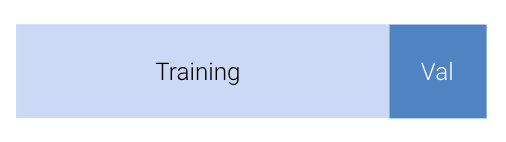

- There are 5 **non-overlapping** “chunks” of training points that we could have designated as the validation set

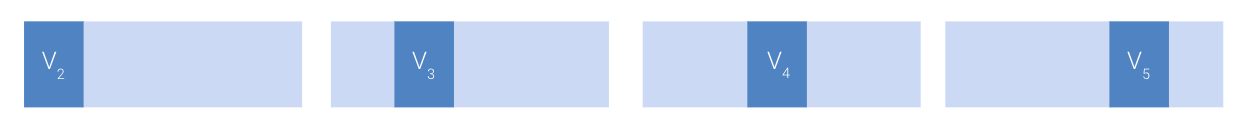

- The common term for one of these chunks is a **fold (折)**

- We really have 5 validation sets “hidden” in our training set

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Cross-Validation**

- In cross-validation, we perform validation splits for each fold in the training set. For a dataset with $K$ folds, we:

1. Pick one fold to be the validation fold
2. Train model of data from every fold **other than** the validation fold
3. Compute the model’s error on the validation fold and record it
4. Repeat for all $K$ folds

- The **cross-validation error** is then the average error across all $K$ validation folds

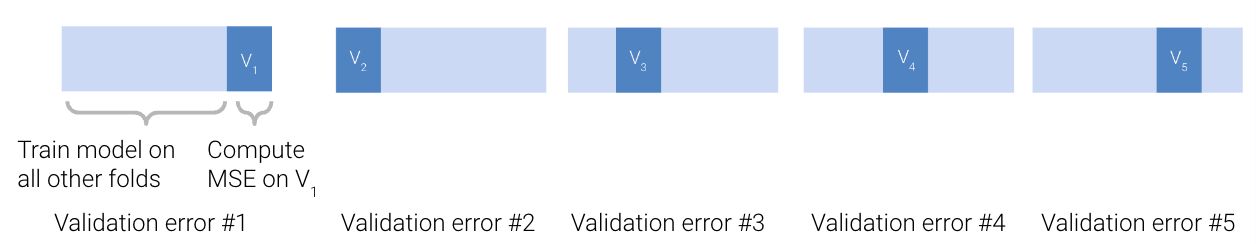

</div>

### Model Selection Workflow

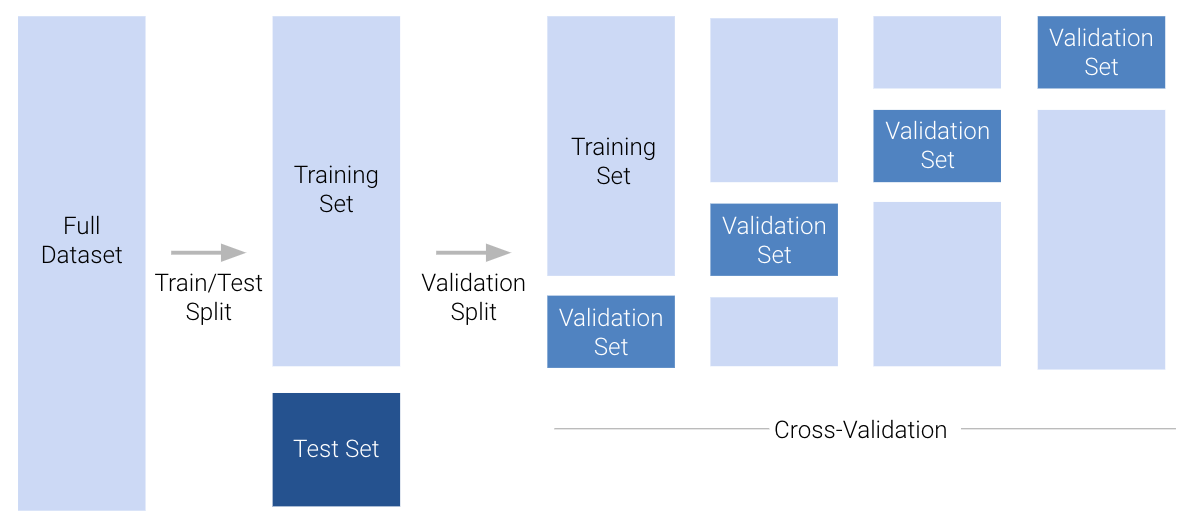

### Hyperparameters

- An important use of cross-validation is for **hyperparameter selection**

- A hyperparameter is some value in a model that is chosen **before** the model is fit to any data
  
  - it is distinct from the model parameters, $θ_i$​, because its value is selected before the training process begins
  
  - We cannot use our usual techniques – calculus, ordinary least squares, or gradient descent – to choose its value. Instead, **we must decide it ourselves**

**Selecting a hyperparameter value via cross-validation**

- First list out several “guesses”

- For each guess, we then run cross-validation to compute the cross-validation error

- We then select the one with **lowest cross-validation error**

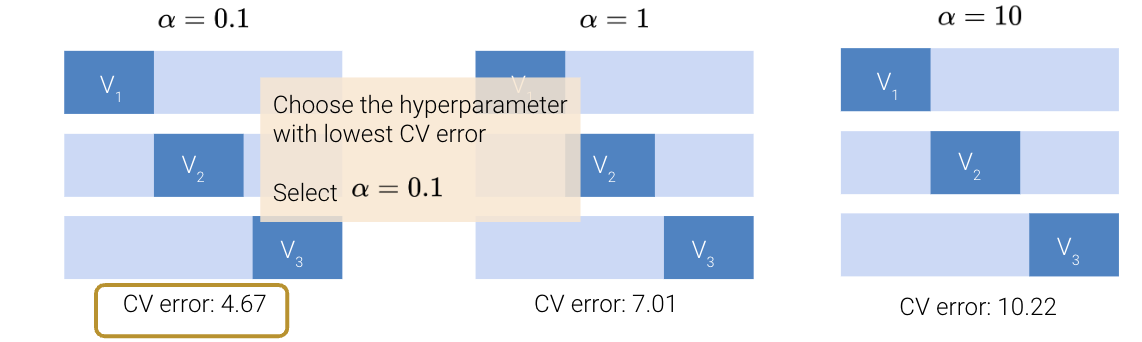

### Pitfalls

- If the dataset is **sorted**, a simple split can produce a validation set that is not representative of the overall data

  - To avoid this, the data should be **shuffled before splitting**

- If data points are **related**, such as paired samples or grouped observations, shuffling can introduce data leakage

  - To prevent this, **related data should be kept together** by using group-based splitting

- When both issues are present, as in time series data, shuffling is not appropriate because it breaks the natural order and dependencies

  - A **sequential approach** should be used: train the model on earlier data and validate it on later data.

## 2 Regularization

- We now introduce a technique to **adjust the model complexity** to tackle underfitting & overfitting

- Earlier, we adjusted the complexity of our polynomial model by tuning a hyperparameter – the degree of the polynomial

- Today we’ll explore two different definitions of complexity: the squared and absolute magnitude of $θ_i$ coefficients

### Constraining Model Parameters

- Notice that the contour map has $p=2$ parameters for ease of visualization. We want to find the model parameters corresponding to the lowest point on the loss surface

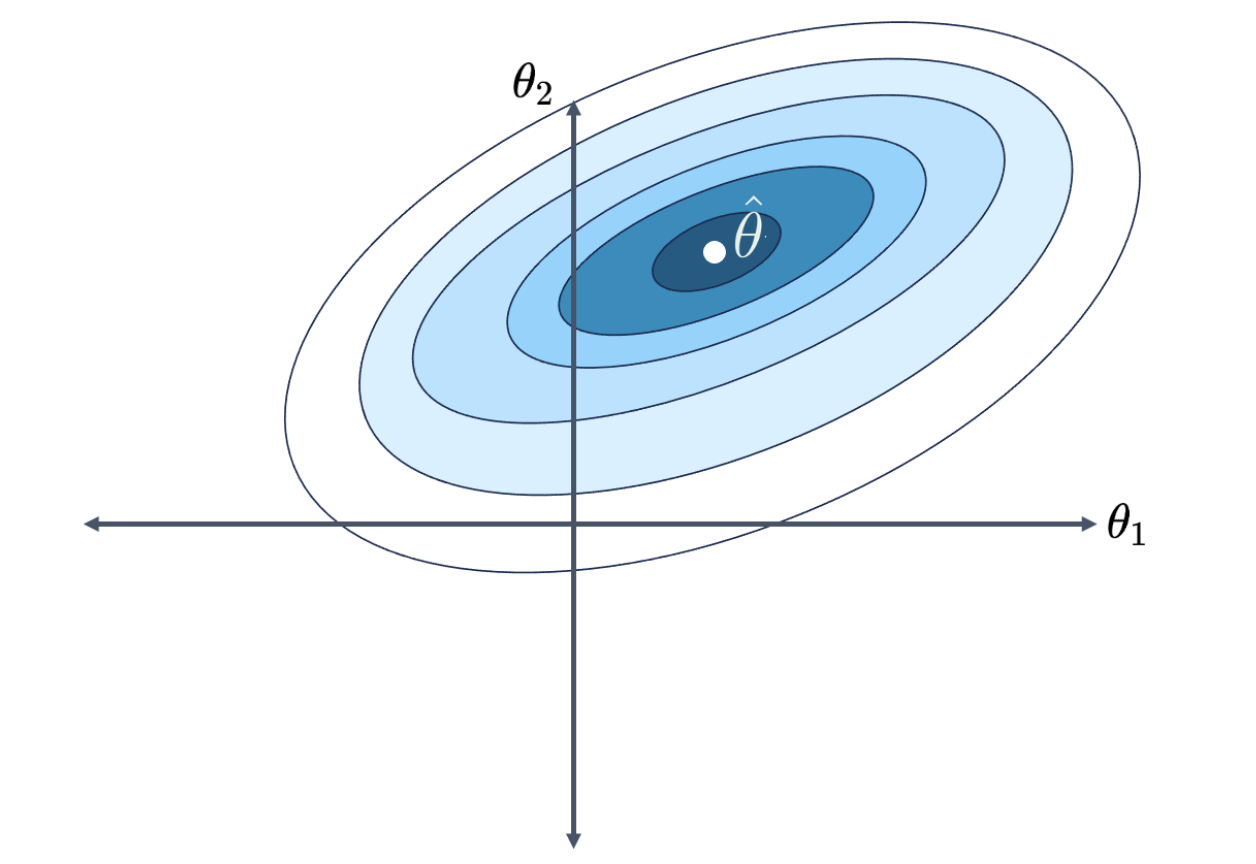

Our current modeling framework is:

$$\hat{Y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p$$

- Previously, we restricted model complexity by limiting the total number of features present in the model; all other polynomials were excluded from the model

- What if, instead of fully removing particular features, we kept all features and **used each one only a “little bit”**?

	- We can **put a limit on how much each feature can contribute** to the predictions to control complexity without manually determine how many features should be included

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **A little Bit?**

- Consider some $\theta_i$ is close to 0, then the corresponding $x_i$ barely impacts the prediction

- So we can put limits on all $\theta$ s to control the impacts of $x$ s

</div>

$$\sum_{i=1}^{p} |\theta_i| \le Q$$

- In **regularization**, we restrict model complexity by putting a limit on thesum of magnitudes of the model parameters $\theta_i$

- We give our model a budget $Q$ for how it distributes the magnitudes of each parameter

<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **Why not separately?**

- Since in this way all features have to compete on how to allocate the quota $Q$, which is also useful in features selection

- If the model assigns a large value to some $θ_i$, it may have to assign a small value to some other $θ_j$

- Ideally, more “important” features will receive greater weighting

</div>

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> **We typically do not regularize the intercept term**

- Since it has no relations with any features

</div>

- Let's say our goal is to find the combination of parameters that gives us the lowest loss

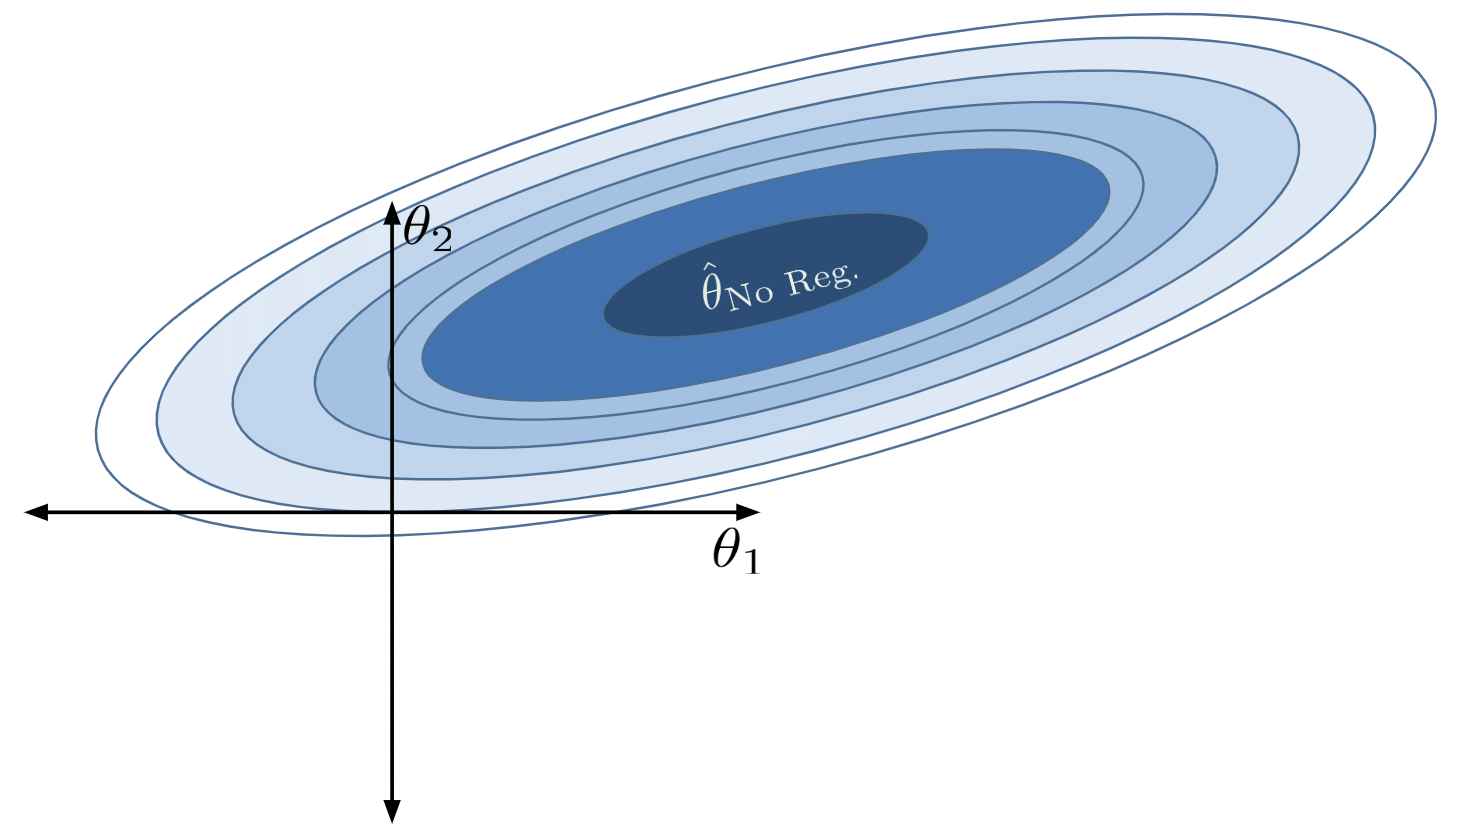

- With no constraint, the optimal $\hat{\theta}$ is in the center, denoted as $\hat{\theta}_{\mathrm{No\ Reg.}}$

- Applying this constraint limits what combinations of model parameters are valid. We can now only consider parameter combinations with a total absolute sum less than or equal to our number $Q$

- $\sum_{i=1}^{p} |\theta_i| \leq Q$ can be rewritten as $|\theta_1| + |\theta_2| \leq Q$ (Green rhombus)

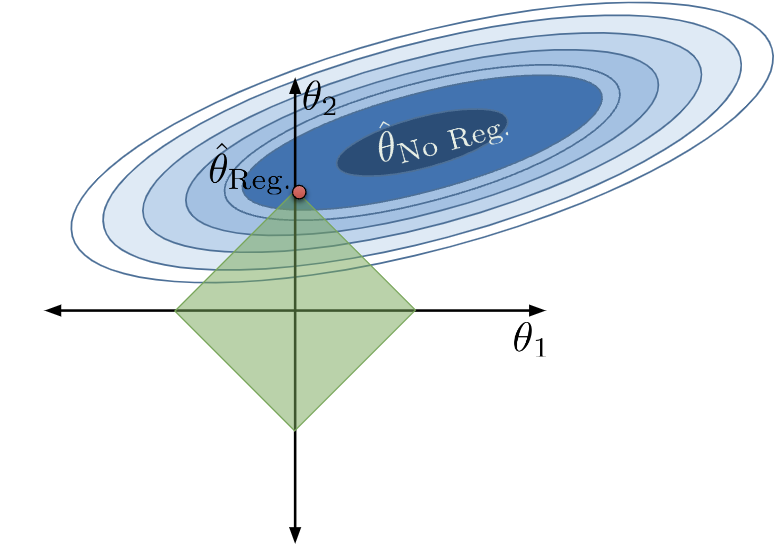

- If we change the value of $Q$, we change the region of allowed parameter combinations

- When $Q$ is small, we severely restrict the size of our parameters $\theta_i$, leading to a much simpler model

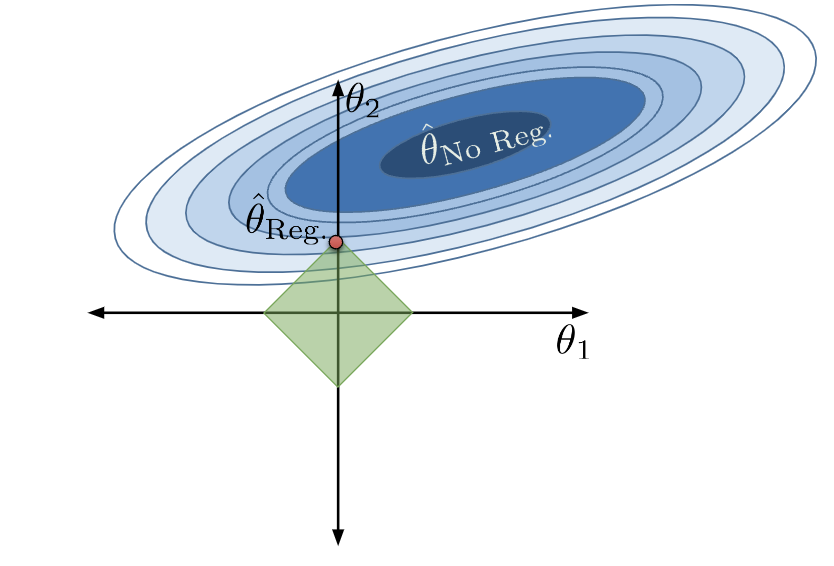

- When $Q$ is large, we do not restrict the size of our parameters $\theta_i$ by much, leading to a more complex model

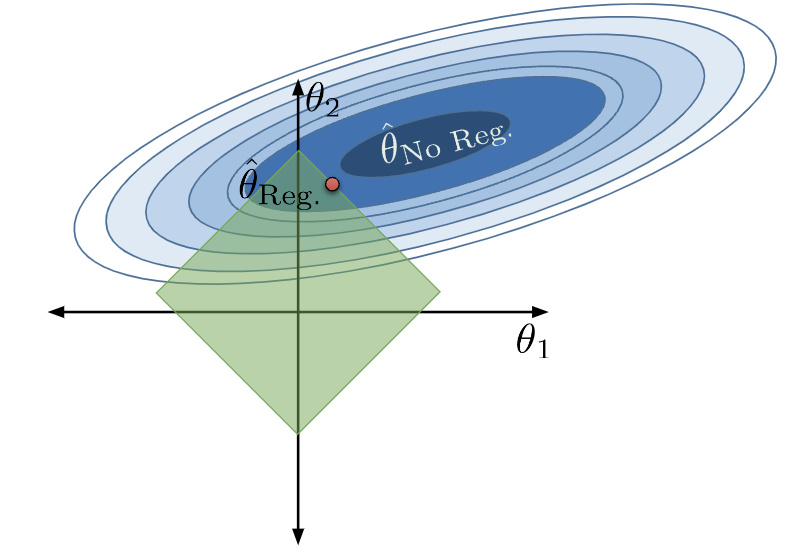

- When $Q$ is extremely large, our restriction has no effect, which can allow us to include the OLS solution

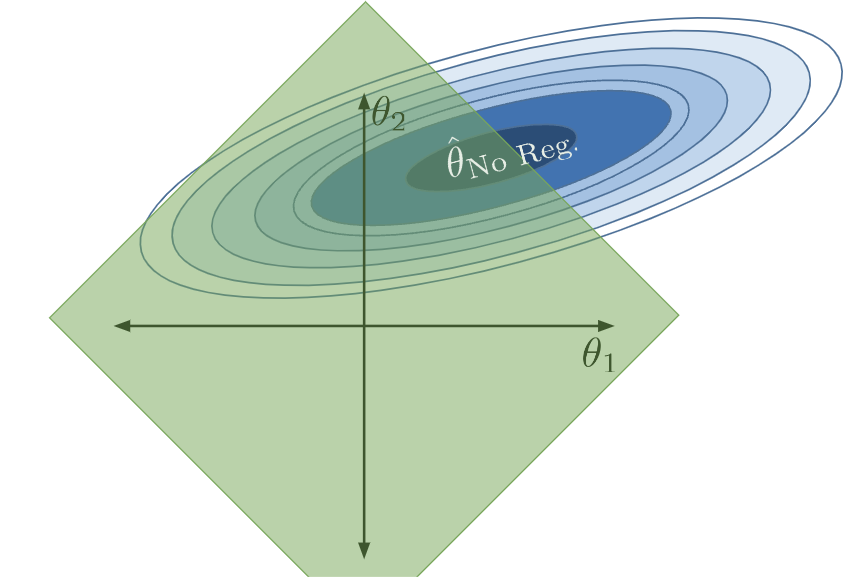

- Obviously, when $Q$ is extremely small (like close to 0), all parameters (except for $\theta_0$) are approaching 0

**Summary**

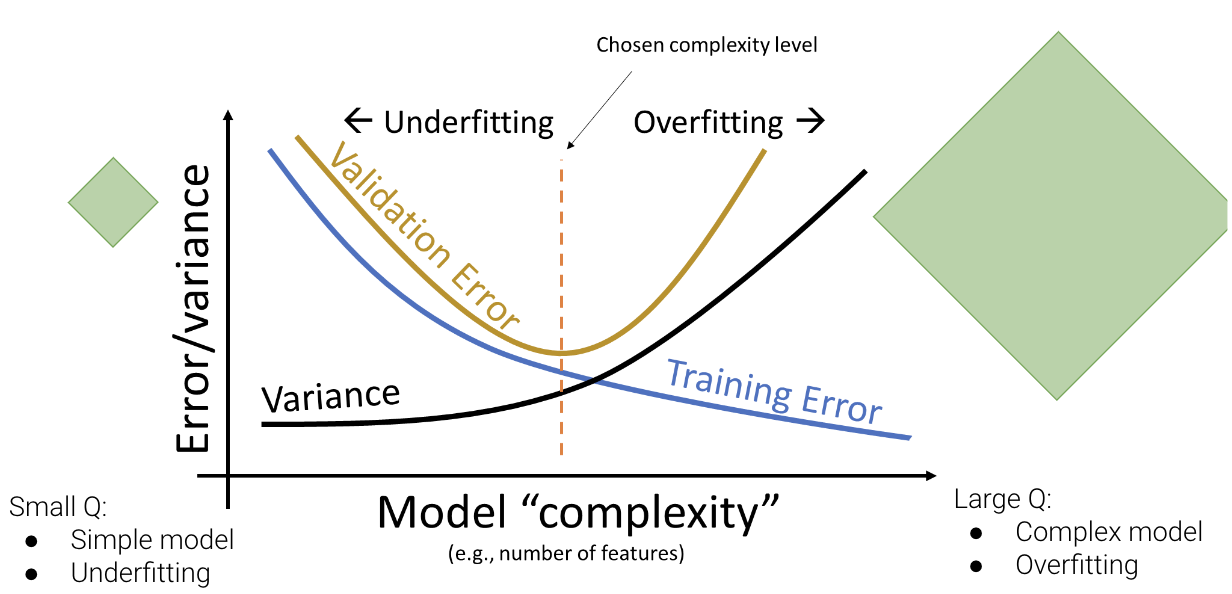

- How to apply our constraint $\sum_{i=1}^{p} |\theta_i| \leq Q$?

- We do it by modifying our **objective func** that we try to minimize

### L1 Regularization (LASSO)

Recall the OLS (Ordinary Least Square) objective func:

$$
\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
=
\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i-\left(
\theta_0+\theta_1x_{i,1}+\theta_2x_{i,2}+\cdots+\theta_px_{i,p}
\right)
\right]^2
$$

To apply our constraint, we need to rephrase our minimization goal as:

$$
\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i-\left(
\theta_0+\theta_1x_{i,1}+\theta_2x_{i,2}+\cdots+\theta_px_{i,p}
\right)
\right]^2
\quad
\text{such that}
\quad
\sum_{i=1}^{p}|\theta_i|\leq Q
$$

**Lagrangian Duality**

- However, we cannot use this formula directly since it is not easy to mathematically optimize over a constraint (Not differentiable over whole area)

- Instead we use [Lagrangian Duality](https://en.wikipedia.org/wiki/Duality_(optimization)) (Details are out of scope)

- It turns out that minimizing the following augmented objective function is **equivalent** to our minimization goal above

$$\frac{1}{n}\sum_{i=1}^{n}
\left(
y_i-\left(
\theta_0+\theta_1x_{i,1}+\theta_2x_{i,2}+\cdots+\theta_px_{i,p}
\right)
\right)^2
+
\lambda\sum_{i=1}^{p}|\theta_i|$$

$$=
\frac{1}{n}\|\mathbf{Y}-\mathbf{X}\boldsymbol{\theta}\|_2^2
+
\lambda\sum_{i=1}^{p}|\theta_i|$$

$$=
\frac{1}{n}\|\mathbf{Y}-\mathbf{X}\boldsymbol{\theta}\|_2^2
+
\lambda\|\boldsymbol{\theta}\|_1$$


- The last two expressions include the MSE expressed using vector notation

- The last expression writes **L1 norm** $\|\boldsymbol{\theta}\|_1$

- We’ve **replaced the constraint with a second term** in our objective function that *penalizes* large coefficients

- $\lambda$ is the regularization penalty hyperparameter

- The process of finding optimal $\hat{\theta}$ to minimize our new objective func is called **L1 Regulation** or **LASSO (Least Absolute Shrinkage and Selection Operator)**

- Unlike OLS where we have a closed-form solution, **LASSO has no closed-form solution**

- We use algorithm to approach

In [10]:
import sklearn.linear_model as lm

# The alpha parameter represents our lambda term
lasso_model = lm.Lasso(alpha=2)
lasso_model.fit(X_train, Y_train)

lasso_model.coef_

array([-2.54932056e-01, -9.48597165e-04,  8.91976284e-06, -1.22872290e-08])

- An important characteristic of L1 regularization is that **many model parameters are set to 0**

- LASSO effectively **selects only a subset** of the features (**Feature Selection**)

  - Features with non-zero parameters are more informative for modeling than those with parameters set to zero

### Scaling Features for Regularization

- The regularization we just performed still has one subtle issue

In [11]:
X_train.head()

,hp,hp^2,hp^3,hp^4
259,85.0,7225.0,614125.0,52200625.0
129,67.0,4489.0,300763.0,20151121.0
207,102.0,10404.0,1061208.0,108243216.0
302,70.0,4900.0,343000.0,24010000.0
71,97.0,9409.0,912673.0,88529281.0


- Our features are on drastically **different numeric scales**

- Features with higher scales will naturally contribute more to prediction in value, hence smaller parameters

In [12]:
pd.DataFrame({"Feature":X_train.columns, "Parameter":lasso_model.coef_})

,Feature,Parameter
0,hp,-2.549321e-01
1,hp^2,-9.485972e-04
2,hp^3,8.919763e-06
3,hp^4,-1.228723e-08


- We can avoid this issue by **scaling** the data before regularizing

- One way to do so is **standardization** (z-scores)

$$z_k = \frac{x_k - \mu_k}{\sigma_k}$$



### L2 Regularization (Ridge)

- We also can apply a different constraint other than L1

- **L2 Regularization (Ridge Regression)** entails constraint like this:

$$\sum_{i=1}^{p}\theta_i^2 \leq Q$$

- We still do not include the intercept

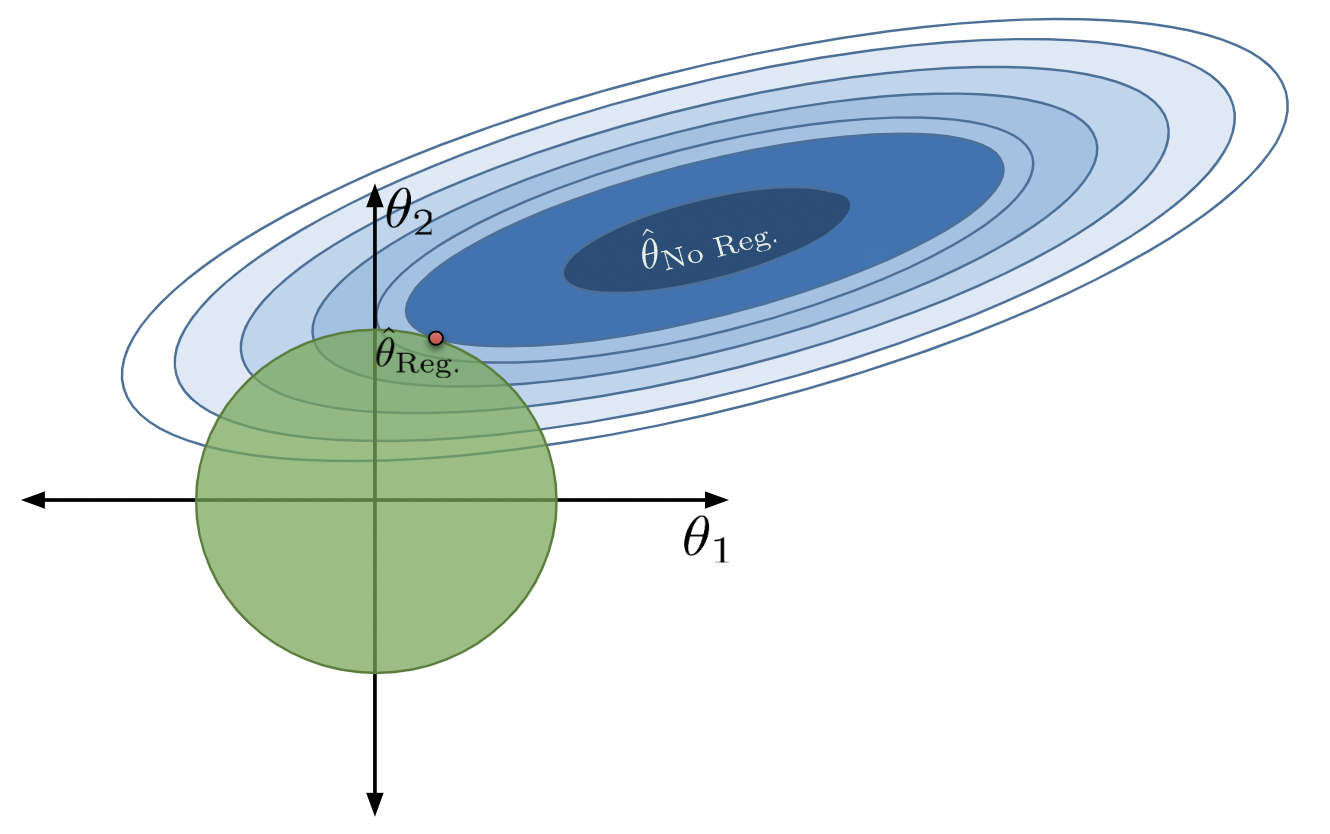

- Unlike L1 regularizaion, **Ridge Regularization does have a closed-form solution**

- This solution exists even if $X$ is not full column rank

- So it is often used since **it can produce a solution even when there is collinearity in the features**

In [13]:
ridge_model = lm.Ridge(alpha=1) # alpha represents the hyperparameter lambda
ridge_model.fit(X_train, Y_train)

ridge_model.coef_

array([ 5.89130559e-02, -6.42445915e-03,  4.44468157e-05, -8.83981945e-08])

### Summary

- Our regression models are summarized below. Note the objective function is what the gradient descent optimizer minimizes

| Type | Model | Loss | Regularization | Objective Function | Solution |
|---|---|---|---|---|---|
| OLS | $\hat{\mathbf{Y}} = \mathbf{X}\boldsymbol{\theta}$ | MSE | None | $\frac{1}{n}\|\mathbf{Y}-\mathbf{X}\boldsymbol{\theta}\|_2^2$ | $\hat{\boldsymbol{\theta}}_{\mathrm{OLS}} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{Y}$ if $\mathbf{X}$ is full-column rank |
| Ridge | $\hat{\mathbf{Y}} = \mathbf{X}\boldsymbol{\theta}$ | MSE | L2 | $\frac{1}{n}\|\mathbf{Y}-\mathbf{X}\boldsymbol{\theta}\|_2^2 + \lambda\sum_{i=1}^{p}\theta_i^2$ | $\hat{\boldsymbol{\theta}}_{\mathrm{ridge}} = (\mathbf{X}^{\top}\mathbf{X}+n\lambda\mathbf{I})^{-1}\mathbf{X}^{\top}\mathbf{Y}$ |
| LASSO | $\hat{\mathbf{Y}} = \mathbf{X}\boldsymbol{\theta}$ | MSE | L1 | $\frac{1}{n}\|\mathbf{Y}-\mathbf{X}\boldsymbol{\theta}\|_2^2+\lambda\sum_{i=1}^{p}\|\theta_i\|$ | No closed-form solution |

---
[Reference](https://ds100.org/course-notes/cv-reg/)